# EDA Framework

For future datasets, remember this sequence:

**Understand → Validate → Clean → Describe → Visualize → Compare → Investigate → Explain → Recommend**

A data analyst should not stop at *"sales decreased."* Continue asking:

**Where? → When? → Which segment/product/customer? → What variables are associated with it? → Is it an anomaly or recurring pattern? → What should the business investigate or do next?**



## Step 1 — Import libraries

In [2]:
import pandas as pd
import plotly.express as px


## Step 2 — Load the dataset


In [3]:
df = pd.read_csv("listings.csv")

keep_columns = [
    "id",
    "name",
    "description",
    "latitude",
    "longitude",
    "neighbourhood_cleansed",
    "property_type",
    "room_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "amenities",
    "price",
    "price_quote_price_per_night",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "last_scraped"
]

df = df[keep_columns].copy()
df

,id,name,description,latitude,longitude,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,...,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,last_scraped
0,13188,Garden level studio in ideal loc.,Garden level studio suite with garden patio - ...,49.247730,-123.105090,Riley Park,Entire guest suite,Entire home/apt,4,1.0,...,122,397,31,4.85,4.86,4.91,4.80,186,55242.0,2026-07-14
1,13358,Downtown Designer suite,Short walk to BC Place<br />Iconic Electra Bui...,49.281174,-123.125931,Downtown,Entire condo,Entire home/apt,2,1.0,...,98,608,33,4.71,4.82,4.91,4.67,198,93917.0,2026-07-14
2,16395,Bright & Spacious 1BR Loft - Downtown Vancouver,We welcome you to a spacious and serene loft c...,49.281220,-123.105270,Downtown Eastside,Entire condo,Entire home/apt,2,1.0,...,127,21,0,4.80,4.94,3.94,4.78,0,0.0,2026-07-14
3,16611,"1 block to skytrain station, shops,restaurant,...","My place is close to bank, coffee shops, groce...",49.263390,-123.071450,Grandview-Woodland,Entire home,Entire home/apt,6,NaN,...,90,3,0,4.00,3.00,5.00,3.67,0,NaN,2026-07-14
4,18270,private rm in clean central 2BR apt,I have a bright furnished 2 bedroom suite on a...,49.265570,-123.096000,Mount Pleasant,Private room in condo,Private room,2,NaN,...,309,118,0,4.54,3.98,4.69,4.49,0,0.0,2026-07-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6619,1727784134515932804,11-2 5 min walk to skytrain,Enjoy easy access to everything from this perf...,49.255081,-123.091626,Riley Park,Private room in home,Private room,2,1.0,...,365,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14
6620,1727877288333409096,Stylish Downtown Waterfront Suite Pool&Gym&Par...,Modern Waterfront Stay in Downtown Vancouver<b...,49.276034,-123.131479,Downtown,Entire rental unit,Entire home/apt,2,1.0,...,345,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14
6621,1728078281519160713,Grand King Suite | 5 Min Airport &10 Min Downt...,Welcome to our spacious 700+ sq. ft. private s...,49.221640,-123.144657,Kerrisdale,Private room in home,Private room,3,1.0,...,355,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14
6622,1728091841063920115,Prestige Executive Suite | Luxury Stay Near YVR,"Welcome to our spacious private suite, inspire...",49.219998,-123.144911,Kerrisdale,Private room in home,Private room,3,2.0,...,354,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14


In [4]:
price_by_location = (
    df.groupby("neighbourhood_cleansed")
      .agg(
          number_of_listings=("id", "count"),
          average_price=("price_quote_price_per_night", "mean"),
          average_latitude=("latitude", "mean"),
          average_longitude=("longitude", "mean")
      )
      .sort_values("number_of_listings", ascending=False)
)
price_by_location

,number_of_listings,average_price,average_latitude,average_longitude
neighbourhood_cleansed,,,,
Downtown,1558,422.188617,49.278806,-123.118875
Kitsilano,453,480.031217,49.266330,-123.164107
Downtown Eastside,429,449.148235,49.280984,-123.099506
Kensington-Cedar Cottage,400,328.854017,49.247319,-123.073936
Mount Pleasant,400,249.402682,49.263185,-123.100169
Hastings-Sunrise,342,309.335130,49.277756,-123.041207
West End,312,332.598313,49.284783,-123.131035
Dunbar Southlands,308,421.595978,49.243118,-123.187229
Riley Park,305,368.373221,49.247481,-123.101136


In [5]:
hh = df.groupby('neighbourhood_cleansed')['price_quote_price_per_night'].agg(['min','max','mean','median'])
hh

,min,max,mean,median
neighbourhood_cleansed,,,,
Arbutus Ridge,38.46,2123.33,426.831739,336.970
Downtown,7.96,5277.60,422.188617,417.500
Downtown Eastside,19.11,1838.00,449.148235,406.000
Dunbar Southlands,12.98,3515.00,421.595978,302.000
Fairview,23.88,91294.50,1073.476286,53.470
Grandview-Woodland,6.09,1277.50,323.316233,307.000
Hastings-Sunrise,8.10,2316.25,309.335130,252.000
Kensington-Cedar Cottage,12.06,1736.00,328.854017,280.500
Kerrisdale,23.54,4000.00,411.188148,275.250


In [6]:
property_type = df.groupby('property_type')['price_quote_price_per_night'].agg(['min','max','mean','median'])
property_type

,min,max,mean,median
property_type,,,,
Boat,1825.89,3496.67,2794.853333,3062.000
Camper/RV,211.00,252.50,242.125000,252.500
Cave,67.12,67.12,67.120000,67.120
Earthen home,241.50,241.50,241.500000,241.500
Entire bungalow,41.27,516.50,263.016667,246.585
Entire condo,19.88,5277.60,386.726203,369.515
Entire cottage,217.00,258.79,237.895000,237.895
Entire guest suite,20.37,3545.50,308.383199,286.500
Entire guesthouse,6.09,1100.00,323.443367,312.480


In [7]:
review_scores_rating = df.groupby('neighbourhood_cleansed')['review_scores_rating'].agg(['min','max','mean','median'])
review_scores_rating

,min,max,mean,median
neighbourhood_cleansed,,,,
Arbutus Ridge,2.33,5.0,4.753561,4.880
Downtown,2.00,5.0,4.826982,4.890
Downtown Eastside,2.67,5.0,4.840256,4.890
Dunbar Southlands,2.00,5.0,4.777549,4.890
Fairview,4.14,5.0,4.780092,4.830
Grandview-Woodland,3.67,5.0,4.857212,4.930
Hastings-Sunrise,3.00,5.0,4.853250,4.920
Kensington-Cedar Cottage,1.00,5.0,4.802274,4.900
Kerrisdale,1.00,5.0,4.734000,4.900


In [8]:
property_type = df.groupby("property_type")["price_quote_price_per_night"].agg(['min','max','mean','median'])
property_type

,min,max,mean,median
property_type,,,,
Boat,1825.89,3496.67,2794.853333,3062.000
Camper/RV,211.00,252.50,242.125000,252.500
Cave,67.12,67.12,67.120000,67.120
Earthen home,241.50,241.50,241.500000,241.500
Entire bungalow,41.27,516.50,263.016667,246.585
Entire condo,19.88,5277.60,386.726203,369.515
Entire cottage,217.00,258.79,237.895000,237.895
Entire guest suite,20.37,3545.50,308.383199,286.500
Entire guesthouse,6.09,1100.00,323.443367,312.480


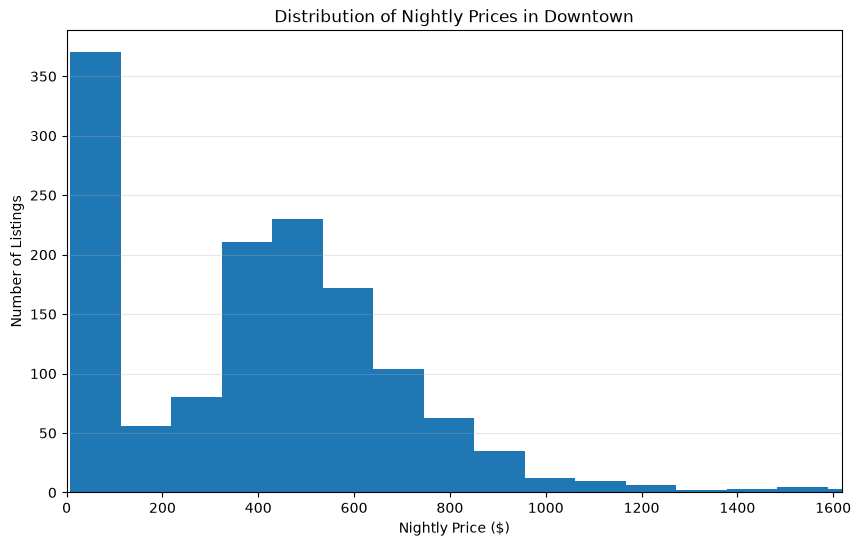

In [9]:
Downtown = df[
    df["neighbourhood_cleansed"] == "Downtown"
].copy()

import matplotlib.pyplot as plt

price_col = "price_quote_price_per_night"

# Use 99th percentile only to make the graph easier to read
price_limit = Downtown[price_col].quantile(0.99)

plt.figure(figsize=(10, 6))

plt.hist(
    Downtown[price_col].dropna(),
    bins=50
)

plt.xlim(0, price_limit)

plt.xlabel("Nightly Price ($)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Nightly Prices in Downtown")

plt.grid(axis="y", alpha=0.3)

plt.show()

C:\Users\tahaj\AppData\Local\Temp\ipykernel_34416\1907179631.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


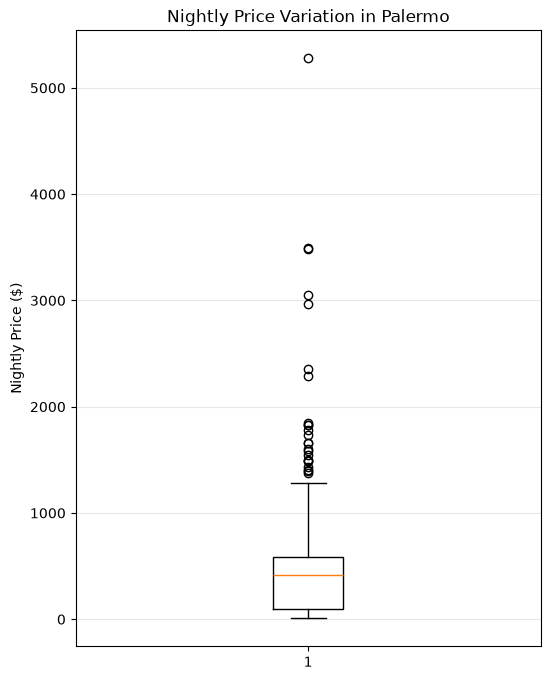

In [10]:
plt.figure(figsize=(6, 8))

plt.boxplot(
    Downtown[price_col].dropna(),
    vert=True,
    showfliers=True
)

plt.ylabel("Nightly Price ($)")
plt.title("Nightly Price Variation in Palermo")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [11]:

lower_price = Downtown[
    Downtown[price_col] <= 500
][price_col].count()

total_price = Downtown[price_col].count()

percentage_lower = (
    lower_price / total_price
) * 100

print("Percentage:", round(percentage_lower, 2), "%")


Percentage: 64.92 %


In [17]:
Downtown["amenity_count"] = (
    Downtown["amenities"]
    .fillna("[]")
    .apply(
        lambda x: 0 if x == "[]" else x.count(",") + 1
    )
)

display(
    Downtown[
        ["amenities", "amenity_count"]
    ].head()
)

,amenities,amenity_count
1,"[""City skyline view"", ""Hot water"", ""Hair dryer...",42
11,"[""Elevator"", ""Iron"", ""Shampoo"", ""Cleaning avai...",59
13,"[""City skyline view"", ""Hot water"", ""Hair dryer...",51
15,"[""Elevator"", ""Iron"", ""Shampoo"", ""Drying rack f...",60
18,"[""Elevator"", ""Iron"", ""Paid street parking off ...",56


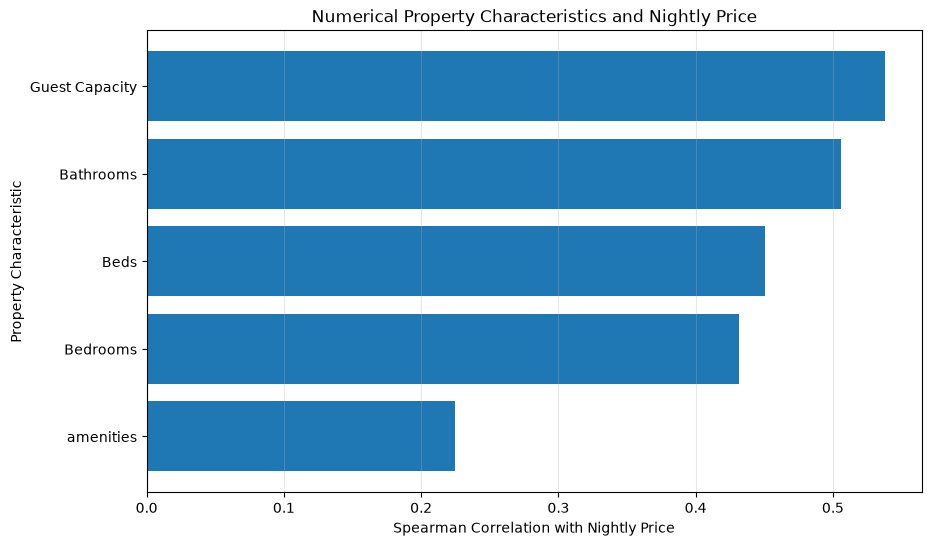

In [18]:
property_features = [
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "amenity_count"
]

property_correlation = (
    Downtown[[price_col] + property_features]
    .corr(method="spearman")[price_col]
    .drop(price_col)
    .sort_values()
)

labels = {
    "accommodates": "Guest Capacity",
    "bedrooms": "Bedrooms",
    "bathrooms": "Bathrooms",
    "beds": "Beds",
    "amenity_count": "amenities"
}

property_correlation.index = [
    labels[x] for x in property_correlation.index
]

plt.figure(figsize=(10, 6))

plt.barh(
    property_correlation.index,
    property_correlation.values
)

plt.axvline(0)

plt.xlabel("Spearman Correlation with Nightly Price")
plt.ylabel("Property Characteristic")
plt.title("Numerical Property Characteristics and Nightly Price")

plt.grid(axis="x", alpha=0.3)

plt.show()

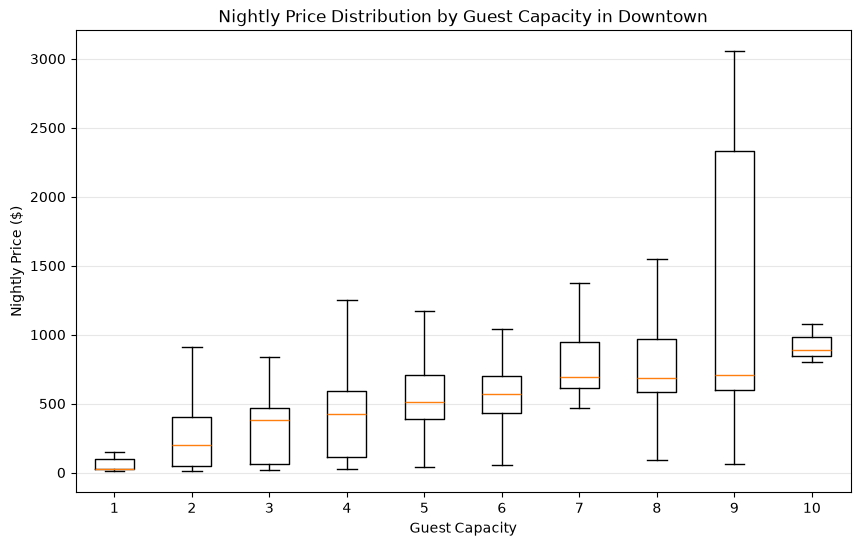

In [19]:
capacity_data = Downtown[
    (Downtown["accommodates"] >= 1) &
    (Downtown["accommodates"] <= 10)
].dropna(
    subset=["accommodates", price_col]
)

groups = [
    capacity_data[
        capacity_data["accommodates"] == capacity
    ][price_col]
    for capacity in range(1, 11)
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    groups,
    tick_labels=range(1, 11),
    showfliers=False
)

plt.xlabel("Guest Capacity")
plt.ylabel("Nightly Price ($)")
plt.title("Nightly Price Distribution by Guest Capacity in Downtown")

plt.grid(axis="y", alpha=0.3)

plt.show()

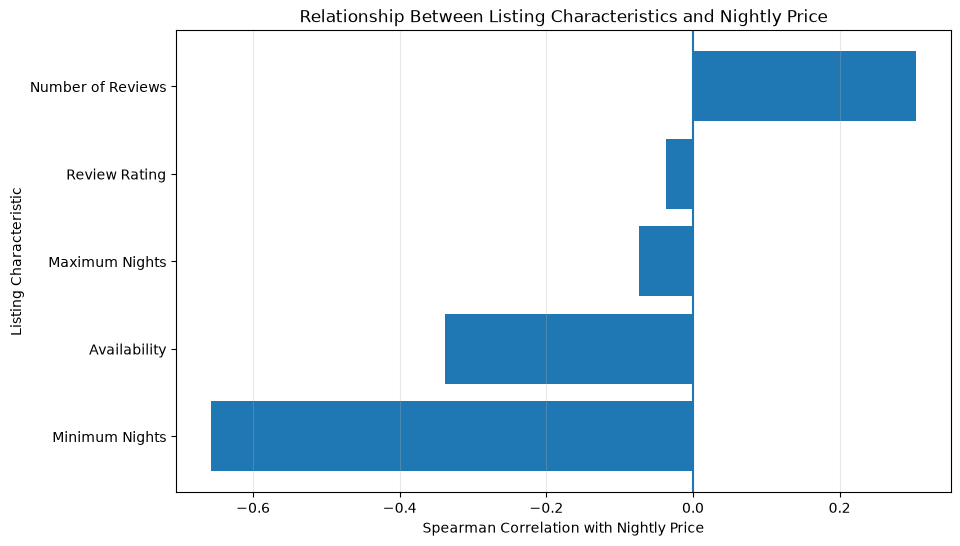

In [20]:
performance_features = [
    "review_scores_rating",
    "number_of_reviews",
    "availability_365",
    "minimum_nights",
    "maximum_nights"
]

performance_correlation = (
    Downtown[
        [price_col] + performance_features
    ]
    .corr(method="spearman")[price_col]
    .drop(price_col)
    .sort_values()
)

labels = {
    "review_scores_rating": "Review Rating",
    "number_of_reviews": "Number of Reviews",
    "availability_365": "Availability",
    "minimum_nights": "Minimum Nights",
    "maximum_nights": "Maximum Nights"
}

performance_correlation.index = [
    labels[x] for x in performance_correlation.index
]

plt.figure(figsize=(10, 6))

plt.barh(
    performance_correlation.index,
    performance_correlation.values
)

plt.axvline(0)

plt.xlabel("Spearman Correlation with Nightly Price")
plt.ylabel("Listing Characteristic")
plt.title("Relationship Between Listing Characteristics and Nightly Price")

plt.grid(axis="x", alpha=0.3)

plt.show()

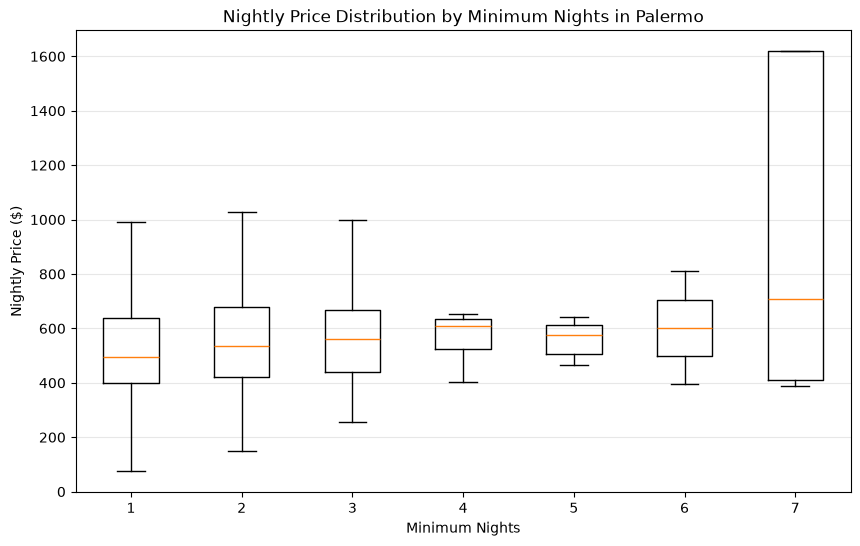

In [24]:
minimum_data = Downtown[
    (Downtown["minimum_nights"] >= 1) &
    (Downtown["minimum_nights"] <= 7)
].dropna(
    subset=["minimum_nights", price_col]
)

groups = [
    minimum_data[
        minimum_data["minimum_nights"] == night
    ][price_col]
    for night in range(1, 8)
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    groups,
    tick_labels=range(1, 8),
    showfliers=False
)

plt.xlabel("Minimum Nights")
plt.ylabel("Nightly Price ($)")
plt.title("Nightly Price Distribution by Minimum Nights in Palermo")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
df.iloc[[224,221]]

,id,name,description,latitude,longitude,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,...,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,last_scraped
224,7478857,Adorable 1 bedroom guesthouse with patio,"Kickback and relax in this calm, stylish, arch...",49.27251,-123.062155,Grandview-Woodland,Entire guesthouse,Entire home/apt,2,1.0,...,49,322,56,4.83,4.88,4.78,4.77,255,38505.0,2026-07-14
221,7183413,Private Garden facing suite with private entrance,Fully private family room (in our own home) wi...,49.27042,-123.069650,Grandview-Woodland,Entire guest suite,Entire home/apt,2,1.0,...,23,222,8,4.97,4.91,4.92,4.89,48,14736.0,2026-07-14



**Ask:** What does one row represent? How many records and columns do we have?

In [ ]:
print(df.shape)
df.dtypes

(6624, 27)


id                               int64
name                               str
description                        str
latitude                       float64
longitude                      float64
neighbourhood_cleansed             str
property_type                      str
room_type                          str
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
amenities                          str
price                              str
price_quote_price_per_night    float64
minimum_nights                 float64
maximum_nights                 float64
availability_365                 int64
number_of_reviews                int64
number_of_reviews_ltm            int64
review_scores_rating           float64
review_scores_cleanliness      float64
review_scores_location         float64
review_scores_value            float64
estimated_occupancy_l365d        int64
estimated_revenue_l365d  

## Step 3 — Understand structure and data types

**Ask:** Are numeric fields numeric? Is the date actually stored as a date?


In [ ]:
print("Rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Rows and columns: (6624, 27)

Column names:
['id', 'name', 'description', 'latitude', 'longitude', 'neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'last_scraped']

Data types:
id                               int64
name                               str
description                        str
latitude                       float64
longitude                      float64
neighbourhood_cleansed             str
property_type                      str
room_type                          str
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                     

,id,name,description,latitude,longitude,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,...,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,last_scraped
0,13188,Garden level studio in ideal loc.,Garden level studio suite with garden patio - ...,49.247730,-123.105090,Riley Park,Entire guest suite,Entire home/apt,4,1.0,...,122,397,31,4.85,4.86,4.91,4.80,186,55242.0,2026-07-14
1,13358,Downtown Designer suite,Short walk to BC Place<br />Iconic Electra Bui...,49.281174,-123.125931,Downtown,Entire condo,Entire home/apt,2,1.0,...,98,608,33,4.71,4.82,4.91,4.67,198,93917.0,2026-07-14
2,16395,Bright & Spacious 1BR Loft - Downtown Vancouver,We welcome you to a spacious and serene loft c...,49.281220,-123.105270,Downtown Eastside,Entire condo,Entire home/apt,2,1.0,...,127,21,0,4.80,4.94,3.94,4.78,0,0.0,2026-07-14
3,16611,"1 block to skytrain station, shops,restaurant,...","My place is close to bank, coffee shops, groce...",49.263390,-123.071450,Grandview-Woodland,Entire home,Entire home/apt,6,NaN,...,90,3,0,4.00,3.00,5.00,3.67,0,NaN,2026-07-14
4,18270,private rm in clean central 2BR apt,I have a bright furnished 2 bedroom suite on a...,49.265570,-123.096000,Mount Pleasant,Private room in condo,Private room,2,NaN,...,309,118,0,4.54,3.98,4.69,4.49,0,0.0,2026-07-14


In [ ]:
numeric_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(include="object").columns

print("Numerical columns:")
print(numeric_columns.tolist())

print("\nCategorical/text columns:")
print(categorical_columns.tolist())

Numerical columns:
['id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']

Categorical/text columns:
['name', 'description', 'neighbourhood_cleansed', 'property_type', 'room_type', 'amenities', 'price', 'last_scraped']


C:\Users\tahaj\AppData\Local\Temp\ipykernel_12304\1644032141.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


**Convert** data to proper type

In [ ]:
df["last_scraped"] = pd.to_datetime(
    df["last_scraped"],
    errors="coerce"
)

## Step 4 — Check missing values

**Ask:** Which columns have missing values, and what percentage is missing?


In [ ]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": missing_percentage
})

missing_table = missing_table[
    missing_table["missing_count"] > 0
]

print(missing_table)

                             missing_count  missing_percentage
bathrooms                             2469           37.273551
bedrooms                               824           12.439614
beds                                  2276           34.359903
description                             44            0.664251
estimated_revenue_l365d                794           11.986715
maximum_nights                           4            0.060386
minimum_nights                           4            0.060386
price                                  794           11.986715
price_quote_price_per_night            794           11.986715
review_scores_cleanliness              964           14.553140
review_scores_location                 964           14.553140
review_scores_rating                   964           14.553140
review_scores_value                    964           14.553140


## Step 5 — Check duplicates and uniqueness

**Ask:** Are there duplicated rows?

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (6624, 27)


## Step 6 — Clean obvious data-quality issues

For practice, we will:
- remove exact duplicate rows;
- fill missing categorical values with `"Unknown"`;

In [ ]:
df["last_scraped"] = pd.to_datetime(
    df["last_scraped"],
    errors="coerce"
)

df["price_numeric"] = pd.to_numeric(
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False),
    errors="coerce"
)

print(df[["price", "price_numeric"]].head(10))

     price  price_numeric
0  $297.00         297.00
1  $474.33         474.33
2  $487.00         487.00
3      NaN            NaN
4   $13.94          13.94
5  $232.00         232.00
6   $37.26          37.26
7   $35.26          35.26
8   $18.24          18.24
9      NaN            NaN


In [ ]:
# Remove exact duplicate rows
df = df.drop_duplicates()

# Fill missing categorical values with "Unknown"
categorical_columns = df.select_dtypes(include="object").columns

df[categorical_columns] = df[categorical_columns].fillna("Unknown")

# Check the result
print("Shape after removing duplicates:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Shape after removing duplicates: (6624, 28)

Missing values:
id                                0
name                              0
description                       0
latitude                          0
longitude                         0
neighbourhood_cleansed            0
property_type                     0
room_type                         0
accommodates                      0
bathrooms                      2469
bedrooms                        824
beds                           2276
amenities                         0
price                             0
price_quote_price_per_night     794
minimum_nights                    4
maximum_nights                    4
availability_365                  0
number_of_reviews                 0
number_of_reviews_ltm             0
review_scores_rating            964
review_scores_cleanliness       964
review_scores_location          964
review_scores_value             964
estimated_occupancy_l365d         0
estimated_revenue_l365d         794
las

C:\Users\tahaj\AppData\Local\Temp\ipykernel_12304\1468005866.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


## Step 7 — Descriptive statistics

**Ask:** What are the typical values, ranges, and variability?


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,6624.0,968750177869862016.0,13188.0,53173761.25,1154268302754696448.0,1570754235802739712.0,1728377771646952704.0,646999665292906112.0
latitude,6624.0,49.260028,49.20227,49.244945,49.265525,49.27878,49.29436,0.021773
longitude,6624.0,-123.110704,-123.222385,-123.130842,-123.10963,-123.083984,-123.02354,0.04111
accommodates,6624.0,3.927083,1.0,2.0,4.0,5.0,16.0,2.212813
bathrooms,4155.0,1.458484,0.5,1.0,1.0,2.0,8.5,0.798348
bedrooms,5800.0,1.855172,1.0,1.0,2.0,2.0,14.0,1.04514
beds,4348.0,2.339006,1.0,1.0,2.0,3.0,12.0,1.314769
price_quote_price_per_night,5830.0,392.514489,6.09,149.21,321.745,496.4775,91294.5,1249.565631
minimum_nights,6620.0,28.337613,1.0,1.0,2.0,90.0,399.0,45.28446
maximum_nights,6620.0,532.909819,3.0,180.0,365.0,1125.0,1125.0,422.679964


In [ ]:
df[
    [
        "price_numeric",
        "price_quote_price_per_night",
        "accommodates",
        "number_of_reviews",
        "review_scores_rating",
        "estimated_occupancy_l365d",
        "estimated_revenue_l365d"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
price_numeric,5830.0,392.514489,1249.565631,6.09,149.21,321.745,496.4775,91294.5
price_quote_price_per_night,5830.0,392.514489,1249.565631,6.09,149.21,321.745,496.4775,91294.5
accommodates,6624.0,3.927083,2.212813,1.00,2.00,4.000,5.0000,16.0
number_of_reviews,6624.0,50.910326,89.544139,0.00,2.00,14.000,61.0000,1169.0
review_scores_rating,5660.0,4.803793,0.345739,1.00,4.76,4.900,5.0000,5.0
estimated_occupancy_l365d,6624.0,87.366244,92.572273,0.00,0.00,48.000,174.0000,255.0
estimated_revenue_l365d,5830.0,35101.223328,77889.867828,0.00,1526.00,16275.500,52534.7500,4929903.0


## Step 8 — Explore categorical variables

**Ask:** What are the most common segments, regions, categories, and shipping modes?


In [ ]:
categorical_cols = df.select_dtypes(include='object')

C:\Users\tahaj\AppData\Local\Temp\ipykernel_12304\2091966587.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object')


**Visualize** the categorical columns

In [ ]:

for col in categorical_cols:

    value_counts = (
        df[col]
        .value_counts()
        .head(12)
        .reset_index()
    )

    value_counts.columns = [col, "Count"]

    fig = px.bar(
        value_counts,
        x=col,
        y="Count",
        text_auto=True,
        title=f"{col.title()} - Frequency Distribution"
    )

    fig.show()

**The most importent categorical columns for me**

In [ ]:
print(df["room_type"].value_counts())
fig = px.bar(
    df["room_type"].value_counts().reset_index(),
    x="room_type",
    y="count",
    title="Number of Listings by Room Type"
)

fig.show()

room_type
Entire home/apt    5410
Private room       1192
Shared room          19
Hotel room            3
Name: count, dtype: int64


In [ ]:
print(df["property_type"].value_counts())
property_counts = (
    df["property_type"]
    .value_counts()
    .reset_index()
)

fig = px.bar(
    property_counts,
    x="count",
    y="property_type",
    orientation="h",
    title="Property Types"
)

fig.show()

property_type
Entire rental unit                    1770
Entire home                           1706
Private room in home                   882
Entire condo                           821
Entire guest suite                     726
Private room in rental unit            121
Entire guesthouse                      109
Entire loft                             84
Entire townhouse                        79
Private room in condo                   62
Entire serviced apartment               53
Private room in townhouse               30
Private room in guest suite             21
Room in hotel                           18
Tiny home                               13
Private room in villa                   13
Private room in bed and breakfast       12
Entire villa                            10
Private room in guesthouse               8
Entire bungalow                          8
Shared room in home                      8
Entire place                             7
Private room in bungalow                

In [ ]:
print(df["neighbourhood_cleansed"].value_counts())
neighbourhood_counts = (
    df["neighbourhood_cleansed"]
    .value_counts()
    .reset_index()
)

fig = px.bar(
    neighbourhood_counts,
    x="count",
    y="neighbourhood_cleansed",
    orientation="h",
    title="Neighbourhoods"
)

fig.show()

neighbourhood_cleansed
Downtown                    1558
Kitsilano                    453
Downtown Eastside            429
Mount Pleasant               400
Kensington-Cedar Cottage     400
Hastings-Sunrise             342
West End                     312
Dunbar Southlands            308
Riley Park                   305
Renfrew-Collingwood          278
Grandview-Woodland           255
Sunset                       239
Victoria-Fraserview          204
Marpole                      194
Arbutus Ridge                153
West Point Grey              139
Fairview                     136
Oakridge                     123
Killarney                    121
Kerrisdale                   114
Shaughnessy                   83
South Cambie                  57
Strathcona                    21
Name: count, dtype: int64


## Step 9 — Explore numerical distributions

Histograms help identify skewness, concentration, and unusual values.


In [ ]:
numbers=df.select_dtypes(include=['number'])

**Visualize** the numerical columns

In [ ]:
for col in numbers:

    fig = px.histogram(df,x=col,
        nbins=30,
        title=f"Distribution of {col.title()}",
        labels={
            col: col.title(),
            "count": "Frequency"
        })

    fig.show()

**The most importent nummerical columns for me**

In [ ]:
numerical_variables = [
    "price_quote_price_per_night",
    "accommodates",
    "bedrooms",
    "beds",
    "number_of_reviews",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

In [ ]:
fig = px.histogram(
    df,
    x="price_quote_price_per_night",
    title="Distribution of Price per Night"
)

fig.show()

In [ ]:
fig = px.histogram(
    df,
    x="estimated_revenue_l365d",
    title="Distribution of Estimated Annual Revenue"
)

fig.show()

In [ ]:
fig = px.histogram(
    df,
    x="estimated_occupancy_l365d",
    title="Distribution of Estimated Occupancy"
)

fig.show()

## Step 10 — Detect outliers using IQR

The common IQR rule defines potential outliers as values below:

`Q1 - 1.5 × IQR`

or above:

`Q3 + 1.5 × IQR`


In [ ]:
def find_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]
    
    print(f"Column: {column}")
    print(f"Lower bound: {lower}")
    print(f"Upper bound: {upper}")
    print(f"Number of outliers: {len(outliers)}")
    
    return outliers

**Importient columns fop me**

In [ ]:
price_outliers = find_outliers(
    "price_quote_price_per_night"
)

Column: price_quote_price_per_night
Lower bound: -371.6912500000001
Upper bound: 1017.3787500000001
Number of outliers: 217


In [ ]:
revenue_outliers = find_outliers(
    "estimated_revenue_l365d"
)

Column: estimated_revenue_l365d
Lower bound: -74987.125
Upper bound: 129047.875
Number of outliers: 251


### Visualize outliers with a box plot

In [ ]:
for col in numeric_columns:
    fig = px.box(
        df,
        y=col,
        title=f"Box Plot: {col.title()}"
    )

    fig.show()

## Step 11 — Analyze relationships between numerical variables

**Ask:** use correlation


In [ ]:
numeric_columns = df.select_dtypes(
    include="number"
).columns

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix)


                                   id  latitude  longitude  accommodates  \
id                           1.000000 -0.121782  -0.014204      0.155549   
latitude                    -0.121782  1.000000  -0.058458     -0.103982   
longitude                   -0.014204 -0.058458   1.000000     -0.006700   
accommodates                 0.155549 -0.103982  -0.006700      1.000000   
bathrooms                    0.098221 -0.109736  -0.064147      0.713009   
bedrooms                     0.099270 -0.201836  -0.006392      0.843300   
beds                         0.076356 -0.105741  -0.005954      0.893258   
price_quote_price_per_night  0.020499  0.024069  -0.039347      0.176371   
minimum_nights              -0.305750  0.126110  -0.045887     -0.232297   
maximum_nights              -0.329177  0.011979  -0.001502      0.028658   
availability_365             0.092263 -0.014869   0.034382     -0.065766   
number_of_reviews           -0.448313  0.038403   0.072328     -0.041653   
number_of_re

In [ ]:
fig = px.scatter_matrix(
    correlation_matrix,
    dimensions=numeric_columns,
    title="Scatter Matrix of Numeric Variables"
)

fig.show()

In [ ]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


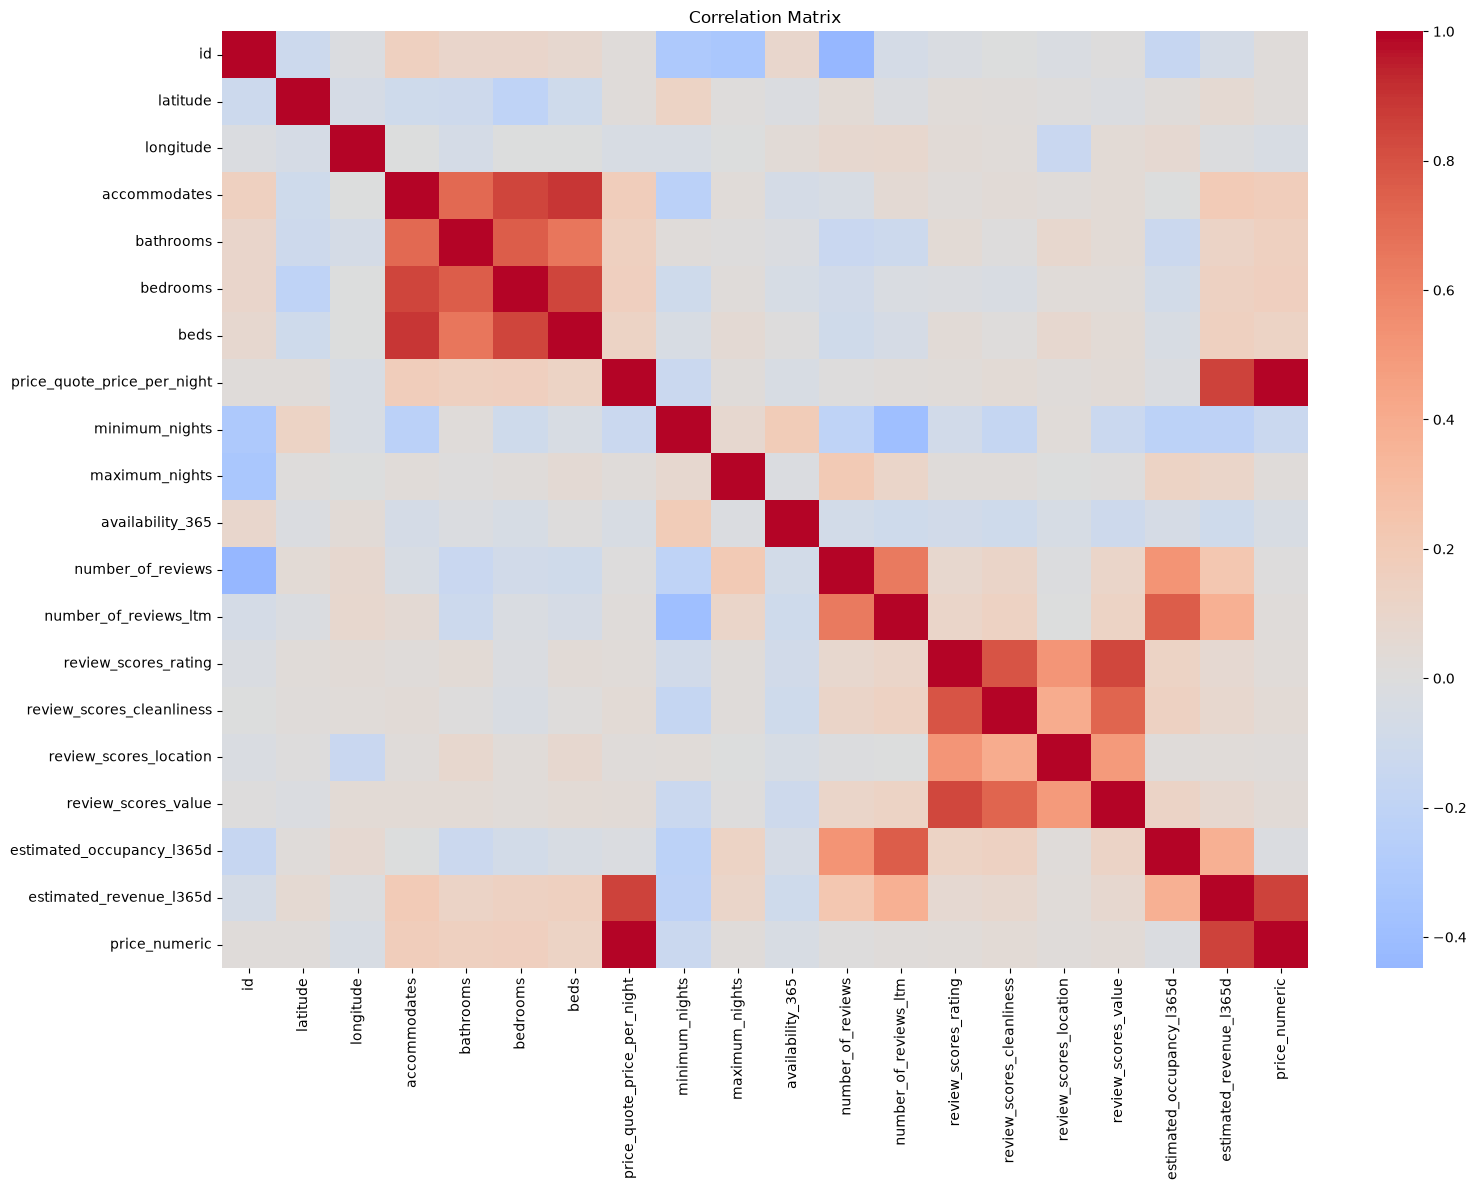

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
revenue_corr = (
    correlation_matrix["estimated_revenue_l365d"]
    .sort_values(ascending=False)
)

print(revenue_corr)

estimated_revenue_l365d        1.000000
price_numeric                  0.851903
price_quote_price_per_night    0.851903
number_of_reviews_ltm          0.380093
estimated_occupancy_l365d      0.374183
number_of_reviews              0.229968
accommodates                   0.200087
beds                           0.151511
bedrooms                       0.148541
bathrooms                      0.120754
maximum_nights                 0.104829
review_scores_cleanliness      0.086977
review_scores_value            0.073439
review_scores_rating           0.071334
latitude                       0.056551
review_scores_location         0.026957
longitude                     -0.011146
id                            -0.067705
availability_365              -0.104027
minimum_nights                -0.214566
Name: estimated_revenue_l365d, dtype: float64


## Step 12 — Compare performance across groups

**Ask:** use Groupby

In [ ]:
room_performance = df.groupby("room_type").agg(
    average_price=(
        "price_quote_price_per_night",
        "mean"
    ),
    average_reviews=(
        "number_of_reviews",
        "mean"
    ),
    average_rating=(
        "review_scores_rating",
        "mean"
    ),
    average_occupancy=(
        "estimated_occupancy_l365d",
        "mean"
    ),
    average_revenue=(
        "estimated_revenue_l365d",
        "mean"
    )
)

room_performance.sort_values(
    "average_revenue",
    ascending=False
)

,average_price,average_reviews,average_rating,average_occupancy,average_revenue
room_type,,,,,
Entire home/apt,441.296718,53.200739,4.829774,91.941405,40017.570349
Shared room,231.247222,32.947368,4.755000,65.526316,24553.333333
Private room,174.040048,40.865772,4.667993,67.169463,12985.240000
Hotel room,NaN,25.333333,4.753333,0.000000,NaN


In [ ]:
neighbourhood_performance = df.groupby(
    "neighbourhood_cleansed"
).agg(
    listings=("id", "count"),
    average_price=(
        "price_quote_price_per_night",
        "mean"
    ),
    average_rating=(
        "review_scores_rating",
        "mean"
    ),
    average_occupancy=(
        "estimated_occupancy_l365d",
        "mean"
    ),
    average_revenue=(
        "estimated_revenue_l365d",
        "mean"
    )
)

neighbourhood_performance.sort_values("average_revenue", ascending=False)


,listings,average_price,average_rating,average_occupancy,average_revenue
neighbourhood_cleansed,,,,,
Fairview,136,1073.476286,4.780092,87.441176,61030.161905
Downtown Eastside,429,449.148235,4.840256,101.974359,46581.721228
Downtown,1558,422.188617,4.826982,94.055841,44226.659389
South Cambie,57,430.943333,4.864255,94.982456,41247.254902
Oakridge,123,422.677478,4.792286,86.682927,41223.852174
Shaughnessy,83,654.657143,4.713836,69.662651,41105.214286
Strathcona,21,356.213158,4.931500,112.428571,40263.842105
Kitsilano,453,480.031217,4.842070,90.554084,37692.875661
Arbutus Ridge,153,426.831739,4.753561,87.104575,36818.528986


## Step 13 — Time-series EDA

**Ask:** what is trend over time? Are some months stronger than others?


In [ ]:
df["last_scraped"] = pd.to_datetime(
    df["last_scraped"],
    errors="coerce"
)

monthly = (
    df.groupby(
        df["last_scraped"].dt.to_period("M")
    )
    .agg(
        listings=("id", "count"),
        average_revenue=(
            "estimated_revenue_l365d",
            "mean"
        ),
        average_price=(
            "price_quote_price_per_night",
            "mean"
        )
    )
    .reset_index()
)

monthly["last_scraped"] = (
    monthly["last_scraped"]
    .dt.to_timestamp()
)

print(monthly)

  last_scraped  listings  average_revenue  average_price
0   2026-07-01      6624     35101.223328     392.514489


In [ ]:
fig = px.line(
    monthly,
    x="last_scraped",
    y="listings",
    markers=True,
    title="Number of Listings Over Time"
)

fig.show()

## Step 14 — Find the best and worst performers

A useful EDA habit is to inspect both extremes rather than only averages.


In [ ]:
best_performers = (
    df[
        [
            "id",
            "name",
            "neighbourhood_cleansed",
            "room_type",
            "price_quote_price_per_night",
            "estimated_occupancy_l365d",
            "estimated_revenue_l365d"
        ]
    ]
    .sort_values(
        "estimated_revenue_l365d",
        ascending=False
    )
    .head(10)
)

display(best_performers)

,id,name,neighbourhood_cleansed,room_type,price_quote_price_per_night,estimated_occupancy_l365d,estimated_revenue_l365d
1443,48082323,"Waterfront home on sea wall, expansive ocean view",Fairview,Entire home/apt,91294.50,54,4929903.0
2549,899582979219569070,Near Trendy Main St/Transit/Nat Bailey/QE Park...,Riley Park,Entire home/apt,3545.50,126,446733.0
3642,1247385149425340914,Luxury Downtown | Balcony | Parking | Sleeps 5,Downtown,Entire home/apt,1390.50,255,354578.0
1202,39973193,"Resort-Style Vancouver Mansion | Indoor Pool, Spa",Oakridge,Entire home/apt,1938.57,174,337311.0
4781,1534476364802036447,The Fendi Villa | Pool&HotTub • 7 min to Downtown,Shaughnessy,Entire home/apt,2878.50,114,328149.0
2637,925104291652055577,Cozy Bungalow| Commercial Drive| Steps To Skyt...,Grandview-Woodland,Entire home/apt,1277.00,255,325635.0
946,32819750,Hygge Haven | Scandi 3BR/2BA | King & Fire Deck,Downtown,Entire home/apt,1827.00,174,317898.0
4709,1518394554142760994,Cozy 2BR/3Bed Condo Downtown + Hot Tub/GYM,Downtown Eastside,Entire home/apt,1552.00,198,307296.0
4029,1363945091519158050,Yaletown 4B3BA FreeParking Near Beach Shops Di...,Downtown,Entire home/apt,1177.51,255,300265.0
2967,1022689507699245578,The Skydeck Penthouse - Panoramic Hot Tub Views,Downtown Eastside,Entire home/apt,1173.25,255,299179.0


In [ ]:
worst_performers = (
    df[
        [
            "id",
            "name",
            "neighbourhood_cleansed",
            "room_type",
            "price_quote_price_per_night",
            "estimated_occupancy_l365d",
            "estimated_revenue_l365d"
        ]
    ]
    .sort_values(
        "estimated_revenue_l365d",
        ascending=True
    )
    .head(10)
)

display(worst_performers)

,id,name,neighbourhood_cleansed,room_type,price_quote_price_per_night,estimated_occupancy_l365d,estimated_revenue_l365d
6613,1726315085716374289,18-small unit 5 min walk to skytrain,Riley Park,Entire home/apt,174.00,0,0.0
4,18270,private rm in clean central 2BR apt,Mount Pleasant,Private room,13.94,0,0.0
6621,1728078281519160713,Grand King Suite | 5 Min Airport &10 Min Downt...,Kerrisdale,Private room,175.00,0,0.0
30,415700,"LARGE PRIVATE ROOM+BATH, KING BED, dedicated e...",Renfrew-Collingwood,Private room,19.10,0,0.0
6620,1727877288333409096,Stylish Downtown Waterfront Suite Pool&Gym&Par...,Downtown,Entire home/apt,539.00,0,0.0
32,461370,"Lovely Queen size private bedroom, luxury home",Killarney,Private room,335.28,0,0.0
6619,1727784134515932804,11-2 5 min walk to skytrain,Riley Park,Private room,137.00,0,0.0
6598,1724168167381020837,Brand New Ocean-View Suite Near Beach & UBC,West Point Grey,Entire home/apt,346.00,0,0.0
6599,1724283960842225635,Deluxe Quadruple room near downtown vancouver,Kensington-Cedar Cottage,Private room,125.00,0,0.0
6600,1724287903852286246,Cozy Private Queen Room near Downtown Vancouver,Kensington-Cedar Cottage,Private room,104.00,0,0.0


## Step 15 — Business questions

Try answering these from the analysis above:

1. Which region generates the highest sales?
2. Which region generates the highest profit?
3. Which category generates the highest sales?
4. Which category is most profitable?
5. Does higher discount appear to reduce profitability?
6. Which orders are unusually large?
7. Are high-sales orders always high-profit orders?
8. Which month has the highest sales?
9. Which customer segment contributes the most revenue?
10. What data-quality issues did we discover?


In [ ]:
#Question 1
#Which room type generates the highest average revenue?
df.groupby("room_type")[
    "estimated_revenue_l365d"
].mean().sort_values(ascending=False)

room_type
Entire home/apt    40017.570349
Shared room        24553.333333
Private room       12985.240000
Hotel room                  NaN
Name: estimated_revenue_l365d, dtype: float64

In [ ]:
#Question 2
#Which neighborhood generates the highest average revenue?
df.groupby("neighbourhood_cleansed")[
    "estimated_revenue_l365d"
].mean().sort_values(ascending=False)

neighbourhood_cleansed
Fairview                    61030.161905
Downtown Eastside           46581.721228
Downtown                    44226.659389
South Cambie                41247.254902
Oakridge                    41223.852174
Shaughnessy                 41105.214286
Strathcona                  40263.842105
Kitsilano                   37692.875661
Arbutus Ridge               36818.528986
Riley Park                  34075.528090
Kensington-Cedar Cottage    31300.894587
Victoria-Fraserview         31238.419689
Renfrew-Collingwood         30775.738095
Kerrisdale                  30469.583333
Grandview-Woodland          29713.762791
Hastings-Sunrise            29142.451299
Marpole                     28679.464706
West Point Grey             26552.276423
Dunbar Southlands           26015.554348
Killarney                   25270.500000
West End                    24142.469880
Sunset                      23990.690909
Mount Pleasant              21630.206997
Name: estimated_revenue_l365d, dty

In [ ]:
#Question 3
#Which property types perform best?
df.groupby("property_type").agg(
    average_revenue=("estimated_revenue_l365d", "mean"),
    average_occupancy=("estimated_occupancy_l365d", "mean"),
    average_rating=("review_scores_rating", "mean"),
    listings=("id", "count")
).sort_values(
    "average_revenue",
    ascending=False
)

,average_revenue,average_occupancy,average_rating,listings
property_type,,,,
Entire townhouse,120470.238095,63.215190,4.868451,79
Tower,113577.000000,102.000000,4.830000,1
Entire place,91548.750000,123.000000,4.901429,7
Entire villa,85078.444444,122.400000,4.829000,10
Private room in serviced apartment,70448.000000,112.200000,4.974000,5
Room in boutique hotel,68583.000000,133.500000,4.105000,2
Entire vacation home,56380.500000,136.500000,4.735000,2
Entire loft,53246.385714,115.250000,4.875375,84
Room in hotel,52915.411765,129.666667,4.781250,18


In [ ]:
#Question 4
#Is higher price associated with higher revenue?
df[
    [
        "price_quote_price_per_night",
        "estimated_revenue_l365d"
    ]
].corr()

,price_quote_price_per_night,estimated_revenue_l365d
price_quote_price_per_night,1.000000,0.851903
estimated_revenue_l365d,0.851903,1.000000


In [ ]:
#Question 5
#Is occupancy associated with revenue?
df[
    [
        "estimated_occupancy_l365d",
        "estimated_revenue_l365d"
    ]
].corr()

,estimated_occupancy_l365d,estimated_revenue_l365d
estimated_occupancy_l365d,1.000000,0.374183
estimated_revenue_l365d,0.374183,1.000000


In [ ]:
#Question 6
#Does a higher rating appear to be associated with higher revenue?
df[
    [
        "review_scores_rating",
        "estimated_revenue_l365d"
    ]
].corr()

,review_scores_rating,estimated_revenue_l365d
review_scores_rating,1.000000,0.071334
estimated_revenue_l365d,0.071334,1.000000


In [ ]:
#Question 7
#Which listings have unusually high revenue?

Q1 = df["estimated_revenue_l365d"].quantile(0.25)
Q3 = df["estimated_revenue_l365d"].quantile(0.75)

IQR = Q3 - Q1

high_revenue = df[
    df["estimated_revenue_l365d"] >
    Q3 + 1.5 * IQR
]

display(
    high_revenue[
        [
            "id",
            "name",
            "room_type",
            "price_quote_price_per_night",
            "estimated_occupancy_l365d",
            "estimated_revenue_l365d"
        ]
    ]
    .sort_values(
        "estimated_revenue_l365d",
        ascending=False
    )
)

,id,name,room_type,price_quote_price_per_night,estimated_occupancy_l365d,estimated_revenue_l365d
1443,48082323,"Waterfront home on sea wall, expansive ocean view",Entire home/apt,91294.50,54,4929903.0
2549,899582979219569070,Near Trendy Main St/Transit/Nat Bailey/QE Park...,Entire home/apt,3545.50,126,446733.0
3642,1247385149425340914,Luxury Downtown | Balcony | Parking | Sleeps 5,Entire home/apt,1390.50,255,354578.0
1202,39973193,"Resort-Style Vancouver Mansion | Indoor Pool, Spa",Entire home/apt,1938.57,174,337311.0
4781,1534476364802036447,The Fendi Villa | Pool&HotTub • 7 min to Downtown,Entire home/apt,2878.50,114,328149.0
...,...,...,...,...,...,...
2833,975709302918357818,Serene Pearl | Modern 1BR Laneway Home,Entire home/apt,514.00,252,129528.0
2757,954518106045879190,"Bright 2BD Condo, Rogers Arena",Entire home/apt,695.99,186,129454.0
3126,1087717738207795598,Central 1BR+Bath Near SkyTrain,Private room,1438.00,90,129420.0
4387,1451223854692944151,"New Townhouse, Oakridge Mall | Skytrain | Parking",Entire home/apt,652.67,198,129229.0


In [ ]:
#Question 8
#Which room type has the highest occupancy?
df.groupby("room_type")[
    "estimated_occupancy_l365d"
].mean().sort_values(ascending=False)

room_type
Entire home/apt    91.941405
Private room       67.169463
Shared room        65.526316
Hotel room          0.000000
Name: estimated_occupancy_l365d, dtype: float64

In [ ]:
#Question 9
#Does accommodation capacity affect revenue?
df[
    [
        "accommodates",
        "estimated_revenue_l365d"
    ]
].corr()

,accommodates,estimated_revenue_l365d
accommodates,1.000000,0.200087
estimated_revenue_l365d,0.200087,1.000000


In [ ]:
# Question 10
# What are the main data-quality issues?

print("Duplicate rows:", df.duplicated().sum())

# Missing values table
missing_table = pd.DataFrame({
    "Missing Value Count": df.isnull().sum(),
    "Missing Value Percentage": (df.isnull().mean() * 100).round(2)
})

print("\nMissing values:")
display(missing_table)

print("\nData types:")
print(df.dtypes)

Duplicate rows: 0

Missing values:


,Missing Value Count,Missing Value Percentage
id,0,0.00
name,0,0.00
description,0,0.00
latitude,0,0.00
longitude,0,0.00
neighbourhood_cleansed,0,0.00
property_type,0,0.00
room_type,0,0.00
accommodates,0,0.00
bathrooms,2469,37.27



Data types:
id                                      int64
name                                      str
description                               str
latitude                              float64
longitude                             float64
neighbourhood_cleansed                    str
property_type                             str
room_type                                 str
accommodates                            int64
bathrooms                             float64
bedrooms                              float64
beds                                  float64
amenities                                 str
price                                     str
price_quote_price_per_night           float64
minimum_nights                        float64
maximum_nights                        float64
availability_365                        int64
number_of_reviews                       int64
number_of_reviews_ltm                   int64
review_scores_rating                  float64
review_scores_cleanli

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,6624.0,968750177869862016.0,13188.0,53173761.25,1154268302754696448.0,1570754235802739712.0,1728377771646952704.0,646999665292906112.0
latitude,6624.0,49.260028,49.20227,49.244945,49.265525,49.27878,49.29436,0.021773
longitude,6624.0,-123.110704,-123.222385,-123.130842,-123.10963,-123.083984,-123.02354,0.04111
accommodates,6624.0,3.927083,1.0,2.0,4.0,5.0,16.0,2.212813
bathrooms,4155.0,1.458484,0.5,1.0,1.0,2.0,8.5,0.798348
bedrooms,5800.0,1.855172,1.0,1.0,2.0,2.0,14.0,1.04514
beds,4348.0,2.339006,1.0,1.0,2.0,3.0,12.0,1.314769
price_quote_price_per_night,5830.0,392.514489,6.09,149.21,321.745,496.4775,91294.5,1249.565631
minimum_nights,6620.0,28.337613,1.0,1.0,2.0,90.0,399.0,45.28446
maximum_nights,6620.0,532.909819,3.0,180.0,365.0,1125.0,1125.0,422.679964


In [ ]:
df['room_type'].unique()

<StringArray>
['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
Length: 4, dtype: str

In [ ]:
df[df['room_type']=='Entire home/apt']

,id,name,description,latitude,longitude,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,...,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,last_scraped,price_numeric
0,13188,Garden level studio in ideal loc.,Garden level studio suite with garden patio - ...,49.247730,-123.105090,Riley Park,Entire guest suite,Entire home/apt,4,1.0,...,397,31,4.85,4.86,4.91,4.80,186,55242.0,2026-07-14,297.00
1,13358,Downtown Designer suite,Short walk to BC Place<br />Iconic Electra Bui...,49.281174,-123.125931,Downtown,Entire condo,Entire home/apt,2,1.0,...,608,33,4.71,4.82,4.91,4.67,198,93917.0,2026-07-14,474.33
2,16395,Bright & Spacious 1BR Loft - Downtown Vancouver,We welcome you to a spacious and serene loft c...,49.281220,-123.105270,Downtown Eastside,Entire condo,Entire home/apt,2,1.0,...,21,0,4.80,4.94,3.94,4.78,0,0.0,2026-07-14,487.00
3,16611,"1 block to skytrain station, shops,restaurant,...","My place is close to bank, coffee shops, groce...",49.263390,-123.071450,Grandview-Woodland,Entire home,Entire home/apt,6,NaN,...,3,0,4.00,3.00,5.00,3.67,0,NaN,2026-07-14,NaN
7,20085,Cozy Oasis Uptown Garden Suite,"Your private, fully furnished suite is central...",49.256360,-123.086360,Kensington-Cedar Cottage,Entire guest suite,Entire home/apt,3,NaN,...,80,0,4.80,4.92,4.53,4.78,0,0.0,2026-07-14,35.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6612,1725604875856880364,Spacious 5BR Entire Home | 3055 sqft | Near UBC,"Welcome to our spacious 5-bedroom, 2.5-bathroo...",49.261212,-123.202202,West Point Grey,Entire home,Entire home/apt,10,2.5,...,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14,605.00
6613,1726315085716374289,18-small unit 5 min walk to skytrain,Enjoy easy access to everything from this perf...,49.252780,-123.091700,Riley Park,Entire home,Entire home/apt,4,1.0,...,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14,174.00
6616,1727272872851872735,- Sunflower cozy home,"Located in the south of Vancouver, it only tak...",49.208060,-123.070290,Victoria-Fraserview,Entire home,Entire home/apt,5,1.0,...,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14,350.57
6618,1727707345880112500,Free Parking Prime Location Downtown Stylish C...,✨ Welcome to Your Luxury Downtown Vancouver Re...,49.279654,-123.124088,Downtown,Entire rental unit,Entire home/apt,4,1.0,...,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14,639.00


In [ ]:
df[df['room_type']=='Private room']

,id,name,description,latitude,longitude,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,...,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,last_scraped,price_numeric
4,18270,private rm in clean central 2BR apt,I have a bright furnished 2 bedroom suite on a...,49.265570,-123.096000,Mount Pleasant,Private room in condo,Private room,2,NaN,...,118,0,4.54,3.98,4.69,4.49,0,0.0,2026-07-14,13.94
5,18589,Commercial Drive B&B,"As hosts, we are welcoming you into our home, ...",49.275690,-123.070570,Grandview-Woodland,Private room in home,Private room,2,1.0,...,662,49,4.98,4.98,4.93,4.96,255,59160.0,2026-07-14,232.00
6,18795,*Best choice in downtown-5 Stars * -2,Unknown,49.282990,-123.130080,West End,Private room in home,Private room,2,NaN,...,131,0,4.56,4.46,4.88,4.50,0,0.0,2026-07-14,37.26
8,21912,Private Room + Attached Bathroom + dedicated e...,"Updated, private room on ground floor of large...",49.233610,-123.052830,Renfrew-Collingwood,Private room in home,Private room,1,NaN,...,417,1,4.73,4.87,4.51,4.77,180,3283.0,2026-07-14,18.24
21,134688,"West view, Transit convenient, clean & comfort...",200 meter from 29th Ave Skytrain. 1 zone tran...,49.243560,-123.047570,Renfrew-Collingwood,Private room in home,Private room,1,NaN,...,49,1,4.63,4.78,4.70,4.63,180,2471.0,2026-07-14,13.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6617,1727319744021929551,简约舒适房间,"A cozy, clean, quiet, and comfortable private ...",49.233520,-123.166030,Kerrisdale,Private room in home,Private room,2,1.0,...,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14,148.00
6619,1727784134515932804,11-2 5 min walk to skytrain,Enjoy easy access to everything from this perf...,49.255081,-123.091626,Riley Park,Private room in home,Private room,2,1.0,...,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14,137.00
6621,1728078281519160713,Grand King Suite | 5 Min Airport &10 Min Downt...,Welcome to our spacious 700+ sq. ft. private s...,49.221640,-123.144657,Kerrisdale,Private room in home,Private room,3,1.0,...,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14,175.00
6622,1728091841063920115,Prestige Executive Suite | Luxury Stay Near YVR,"Welcome to our spacious private suite, inspire...",49.219998,-123.144911,Kerrisdale,Private room in home,Private room,3,2.0,...,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14,185.00


In [ ]:
df[df['room_type']=='Hotel room'] 

,id,name,description,latitude,longitude,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,...,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,last_scraped,price_numeric
623,22505866,House On Dunbar B&B - 2010 Room,** ADDITIONAL ROOMS AVAILABLE AT LOWER NIGHTLY...,49.25537,-123.19077,Dunbar Southlands,Room in bed and breakfast,Hotel room,2,NaN,...,35,0,4.77,4.74,4.80,4.74,0,NaN,2026-07-14,NaN
784,26777676,House On Dunbar B&B - Kitsilano Room,"Located in the Dunbar neighbourhood, just 20 m...",49.25412,-123.19050,Dunbar Southlands,Room in bed and breakfast,Hotel room,2,NaN,...,16,0,4.81,4.75,4.81,4.69,0,NaN,2026-07-14,NaN
790,26872346,House On Dunbar B&B - UBC Room,House On Dunbar B&B has been happily welcoming...,49.25495,-123.19067,Dunbar Southlands,Room in bed and breakfast,Hotel room,2,NaN,...,25,0,4.68,4.88,4.88,4.40,0,NaN,2026-07-14,NaN


In [ ]:
df[df['room_type']=='Shared room'] 

,id,name,description,latitude,longitude,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,...,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,last_scraped,price_numeric
510,19073601,amazing view and awesome amenities,In the heart of downtown Vancouver 1 block fro...,49.286310,-123.122530,Downtown,Shared room in rental unit,Shared room,2,NaN,...,33,0,4.82,4.85,5.00,4.74,0,0.0,2026-07-14,34.25
1604,51929808,Bed in 4-Bed Female Only Dorm,Samesun Vancouver is located in the Granville ...,49.280010,-123.122410,Downtown,Shared room in hostel,Shared room,1,NaN,...,95,20,4.41,4.19,4.49,4.24,120,14520.0,2026-07-14,121.00
1893,643084005402678749,Small room,"Central condo , space to share with a couple a...",49.275850,-123.131700,Downtown,Shared room in condo,Shared room,2,1.0,...,38,5,4.37,3.82,4.76,4.37,30,5970.0,2026-07-14,199.00
3385,1173505339219229333,Near UBC house 1,This stylish house newly built in 2016 is perf...,49.235487,-123.202732,Dunbar Southlands,Shared room in home,Shared room,3,NaN,...,21,6,4.62,4.38,4.81,4.71,36,9906.0,2026-07-14,275.16
3392,1174101774567960294,Your Vancouver Getaway!,Welcome to our downtown Vancouver Airbnb!<br /...,49.277940,-123.108420,Downtown,Shared room in rental unit,Shared room,3,1.0,...,191,95,4.93,4.94,4.86,4.82,255,74715.0,2026-07-14,293.00
3610,1234937371137281689,"Loft in Vancouver (private floor, no door)",Stay with me in Vancouver on your own private ...,49.289890,-123.047820,Hastings-Sunrise,Shared room in home,Shared room,2,NaN,...,50,30,4.94,4.94,4.86,4.90,180,NaN,2026-07-14,NaN
3737,1279487802406443189,Luxurious 5BR Villa w/Sauna,Welcome to this stunning 5000+ sq. ft. villa i...,49.222582,-123.129358,Oakridge,Shared room in home,Shared room,16,5.5,...,89,56,4.75,4.79,4.84,4.66,255,297279.0,2026-07-14,1165.80
3746,1282862870247480766,4-Bedroom Home with Balcony,Relax with the whole family in this peaceful h...,49.246178,-123.152249,Arbutus Ridge,Shared room in home,Shared room,4,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0.0,2026-07-14,216.18
4164,1398569335863218479,Bed in 4-Bed Mixed Dorm,Samesun Vancouver is located in the Granville ...,49.278912,-123.123155,Downtown,Shared room in hotel,Shared room,1,NaN,...,4,2,4.75,4.75,4.50,4.75,12,1452.0,2026-07-14,121.00
4166,1398636268100552567,Bed in 8-Bed Mixed Dorm,Samesun Vancouver is located in the Granville ...,49.278912,-123.123155,Downtown,Shared room in hotel,Shared room,1,NaN,...,4,4,5.00,5.00,5.00,4.75,24,2544.0,2026-07-14,106.00
